In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

## DataLoading

In [25]:
df = pd.read_csv(r'loan_data.csv')
df.head(3)

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0


## EDA

In [26]:
df.columns

Index(['credit.policy', 'purpose', 'int.rate', 'installment', 'log.annual.inc',
       'dti', 'fico', 'days.with.cr.line', 'revol.bal', 'revol.util',
       'inq.last.6mths', 'delinq.2yrs', 'pub.rec', 'not.fully.paid'],
      dtype='object')

In [27]:
df.shape

(9578, 14)

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   credit.policy      9578 non-null   int64  
 1   purpose            9578 non-null   object 
 2   int.rate           9578 non-null   float64
 3   installment        9578 non-null   float64
 4   log.annual.inc     9578 non-null   float64
 5   dti                9578 non-null   float64
 6   fico               9578 non-null   int64  
 7   days.with.cr.line  9578 non-null   float64
 8   revol.bal          9578 non-null   int64  
 9   revol.util         9578 non-null   float64
 10  inq.last.6mths     9578 non-null   int64  
 11  delinq.2yrs        9578 non-null   int64  
 12  pub.rec            9578 non-null   int64  
 13  not.fully.paid     9578 non-null   int64  
dtypes: float64(6), int64(7), object(1)
memory usage: 1.0+ MB


In [29]:
df.isnull().sum()

credit.policy        0
purpose              0
int.rate             0
installment          0
log.annual.inc       0
dti                  0
fico                 0
days.with.cr.line    0
revol.bal            0
revol.util           0
inq.last.6mths       0
delinq.2yrs          0
pub.rec              0
not.fully.paid       0
dtype: int64

In [30]:
df.duplicated().sum()

np.int64(0)

In [31]:
df.describe()

,credit.policy,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
count,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9.578000e+03,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000
mean,0.804970,0.122640,319.089413,10.932117,12.606679,710.846314,4560.767197,1.691396e+04,46.799236,1.577469,0.163708,0.062122,0.160054
std,0.396245,0.026847,207.071301,0.614813,6.883970,37.970537,2496.930377,3.375619e+04,29.014417,2.200245,0.546215,0.262126,0.366676
min,0.000000,0.060000,15.670000,7.547502,0.000000,612.000000,178.958333,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.103900,163.770000,10.558414,7.212500,682.000000,2820.000000,3.187000e+03,22.600000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.122100,268.950000,10.928884,12.665000,707.000000,4139.958333,8.596000e+03,46.300000,1.000000,0.000000,0.000000,0.000000
75%,1.000000,0.140700,432.762500,11.291293,17.950000,737.000000,5730.000000,1.824950e+04,70.900000,2.000000,0.000000,0.000000,0.000000
max,1.000000,0.216400,940.140000,14.528354,29.960000,827.000000,17639.958330,1.207359e+06,119.000000,33.000000,13.000000,5.000000,1.000000


<Axes: xlabel='not.fully.paid', ylabel='count'>

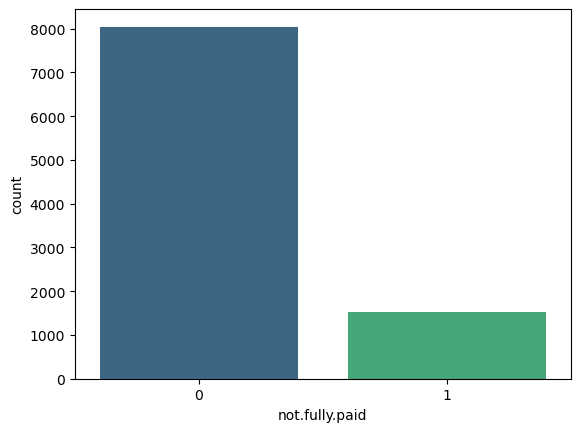

In [32]:
sns.countplot(x='not.fully.paid', data=df, palette = 'viridis')

In [33]:
numerical_col = ['installment', 'log.annual.inc', 'dti', 'fico', 'days.with.cr.line', 'revol.bal', 'revol.util']

df[numerical_col].head(3)

,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util
0,829.10,11.350407,19.48,737,5639.958333,28854,52.1
1,228.22,11.082143,14.29,707,2760.000000,33623,76.7
2,366.86,10.373491,11.63,682,4710.000000,3511,25.6


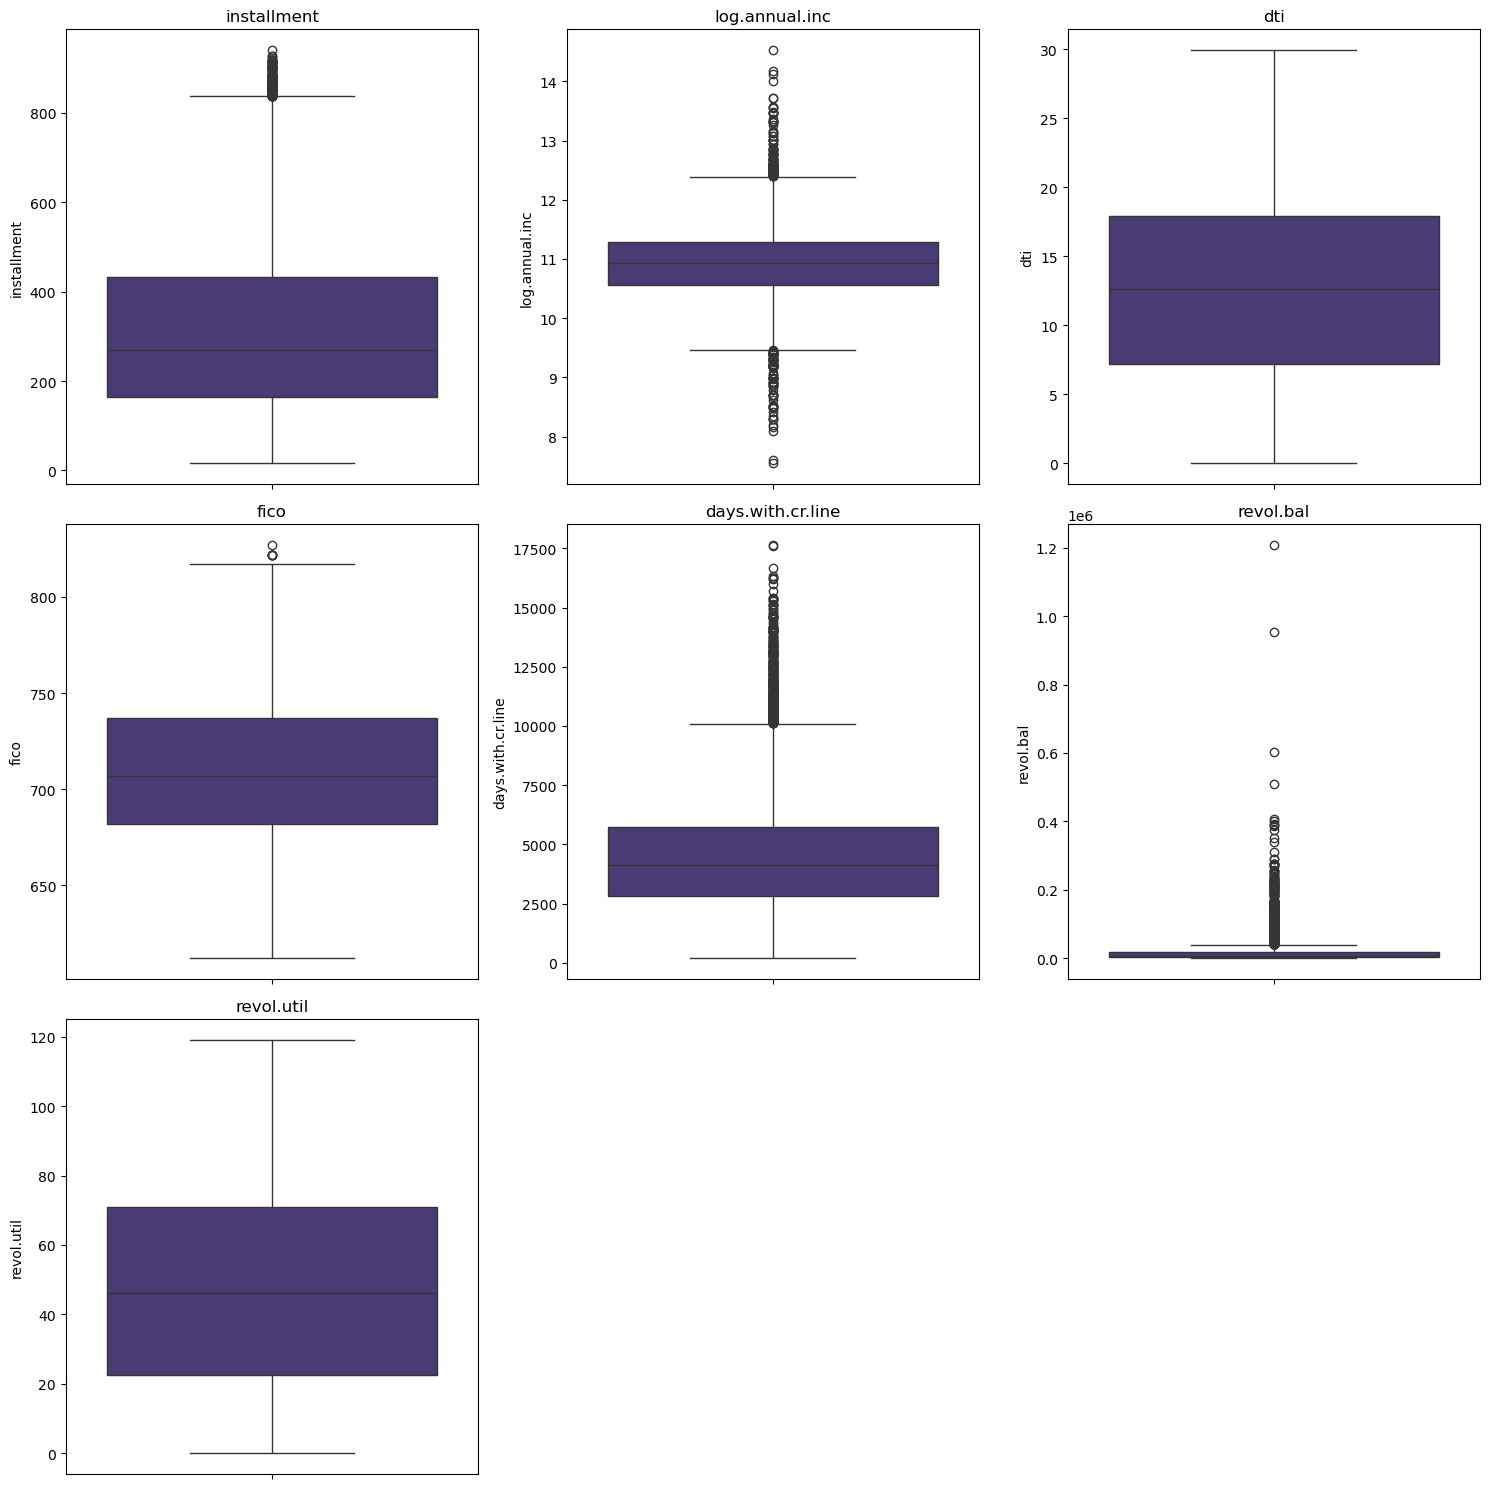

In [34]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 15))
axes = axes.flatten()

for i, col in enumerate(numerical_col):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

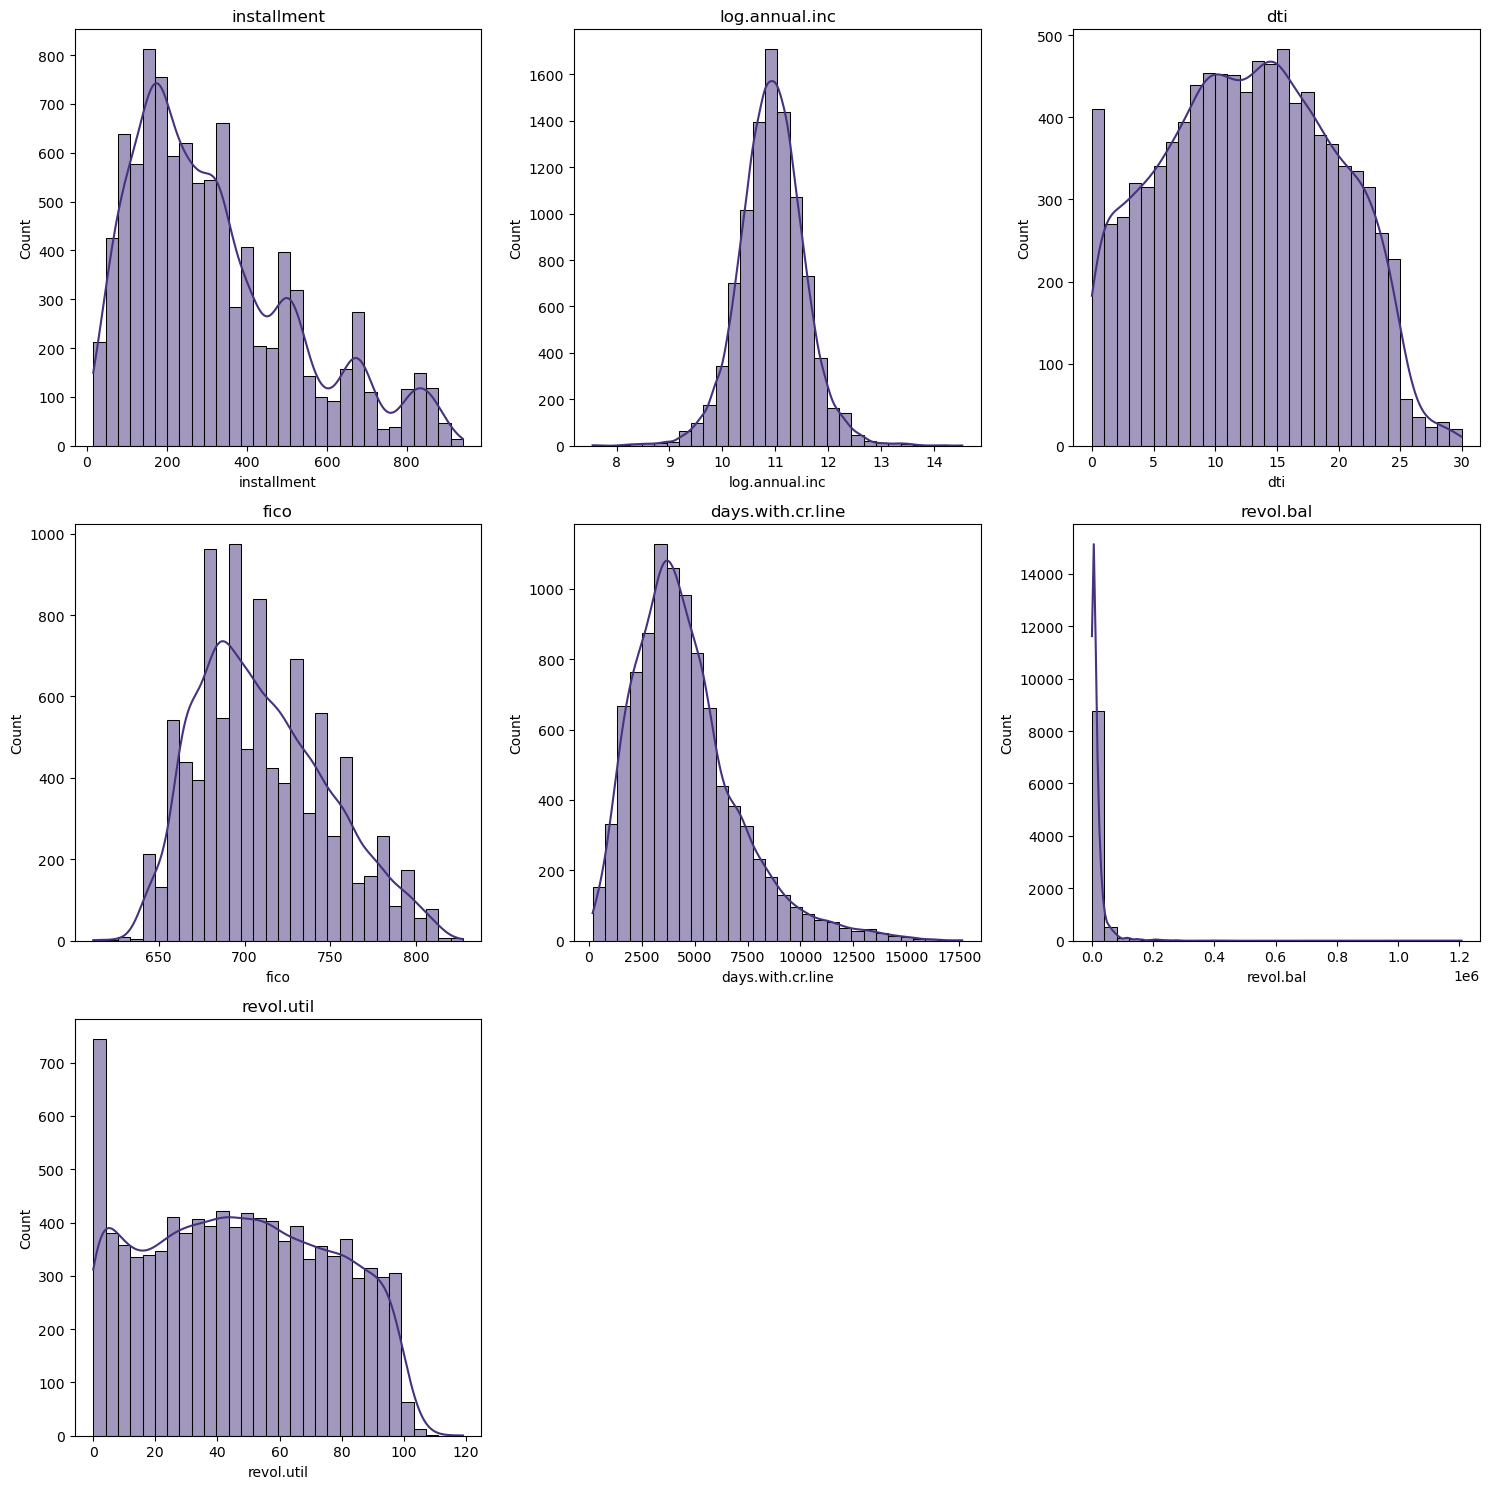

In [35]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 15))
axes = axes.flatten()
sns.set_palette('viridis')

for i, col in enumerate(numerical_col):
    sns.histplot(x=df[col], ax=axes[i], kde = True, bins = 30)
    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

<Axes: xlabel='count', ylabel='purpose'>

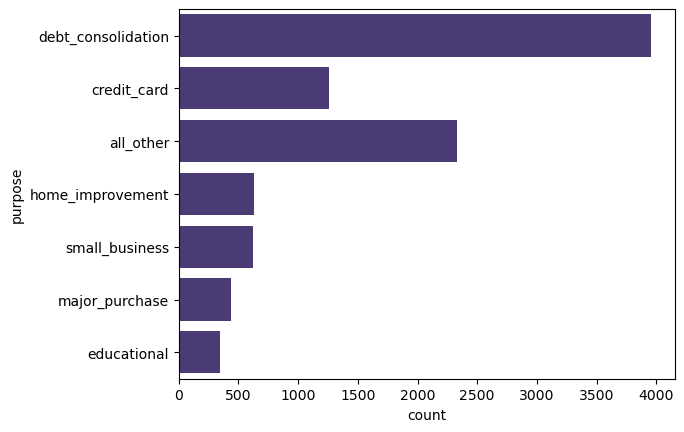

In [36]:
sns.countplot(df['purpose'])

<Axes: xlabel='purpose', ylabel='not.fully.paid'>

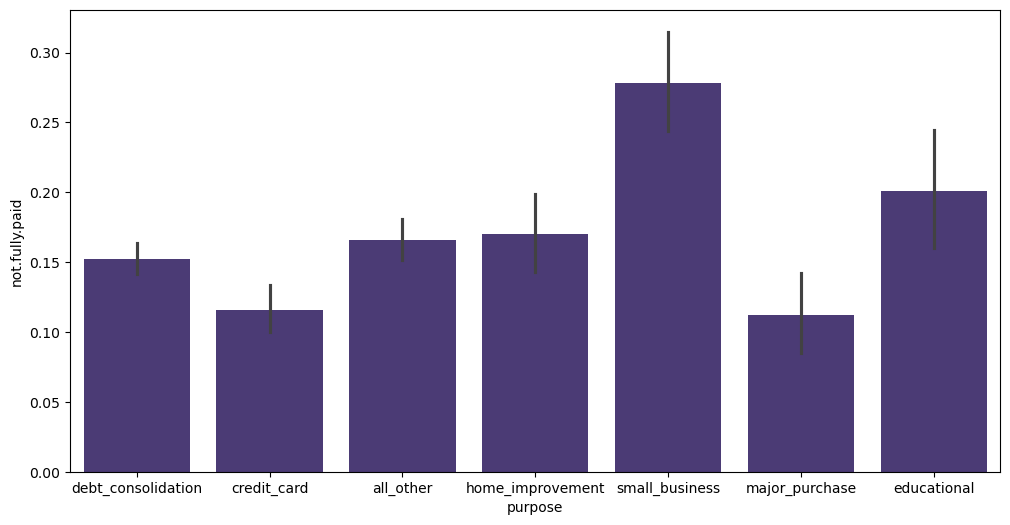

In [37]:
plt.figure(figsize = (12,6))

sns.barplot(y = df['not.fully.paid'], x = df['purpose'])

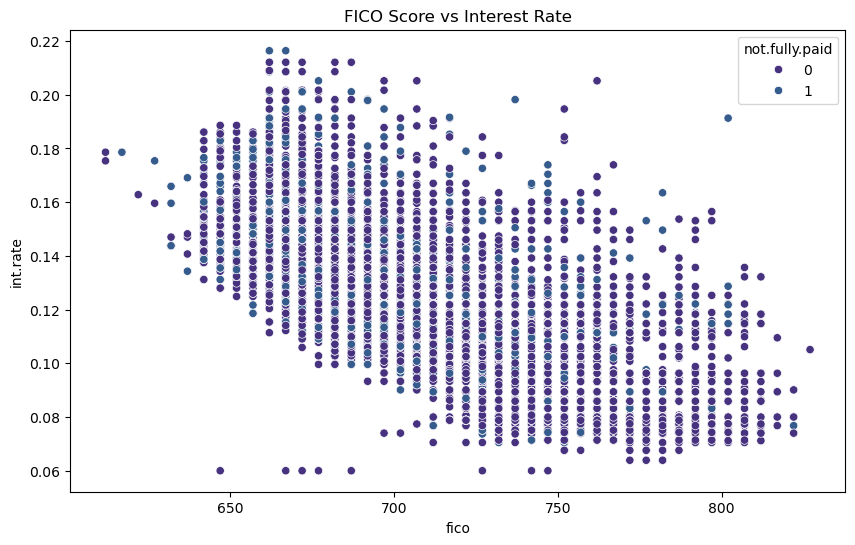

In [38]:
plt.figure(figsize=(10, 6))

sns.scatterplot(x=df['fico'], y=df['int.rate'], hue=df['not.fully.paid'])

plt.title('FICO Score vs Interest Rate')
plt.show()

<Axes: >

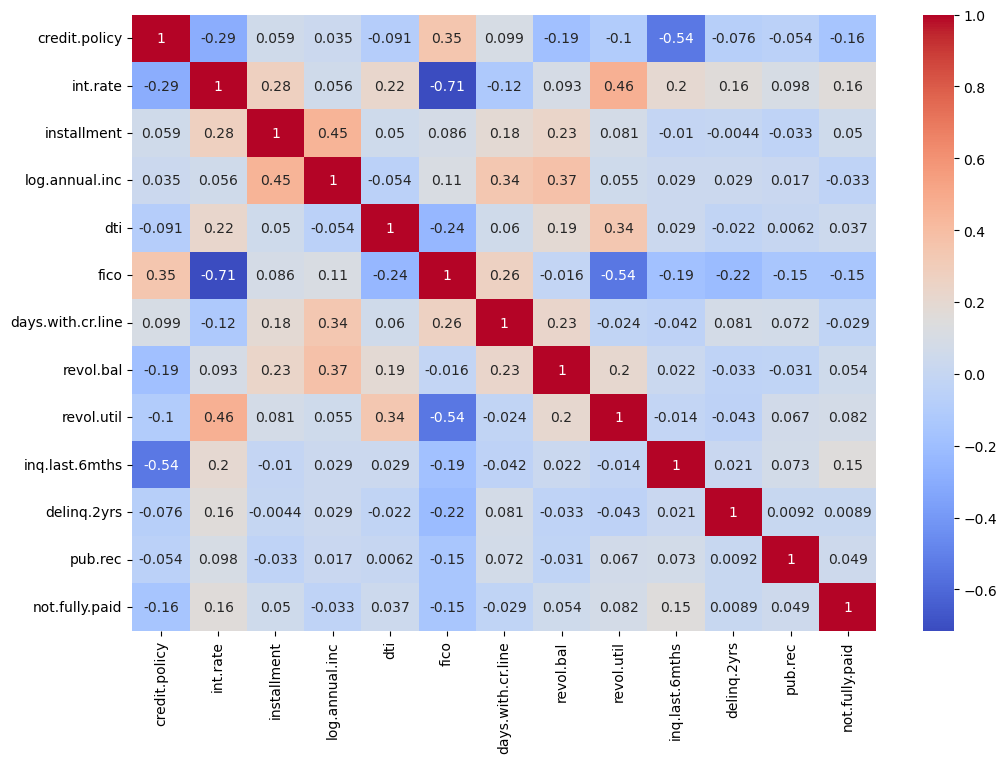

In [39]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm', annot = True)

## Data Cleaning

### Outlier Handling

In [40]:
outliers_col = ['installment', 'days.with.cr.line', 'revol.bal']

for i in outliers_col:
    Q1 = df[i].quantile(0.25)
    Q3 = df[i].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q1 + 1.5 * IQR

    print(f"Column: {i}")
    print(f"  Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
    print(f"  Bounds: [{lower_bound:.2f}, {upper_bound:.2f}]\n")

    df[i] = df[i].clip(upper = upper_bound) 

Column: installment
  Q1: 163.77, Q3: 432.76, IQR: 268.99
  Bounds: [-239.72, 567.26]

Column: days.with.cr.line
  Q1: 2820.00, Q3: 5730.00, IQR: 2910.00
  Bounds: [-1545.00, 7185.00]

Column: revol.bal
  Q1: 3187.00, Q3: 18249.50, IQR: 15062.50
  Bounds: [-19406.75, 25780.75]



In [41]:
Q1 = df['log.annual.inc'].quantile(0.25)
Q3 = df['log.annual.inc'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q1 + 1.5 * IQR

print(f"Column: {'log.annual.inc'}")
print(f"  Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
print(f"  Bounds: [{lower_bound:.2f}, {upper_bound:.2f}]\n")

df['log.annual.inc'] = df['log.annual.inc'].clip(lower = lower_bound, upper = upper_bound)

Column: log.annual.inc
  Q1: 10.56, Q3: 11.29, IQR: 0.73
  Bounds: [9.46, 11.66]



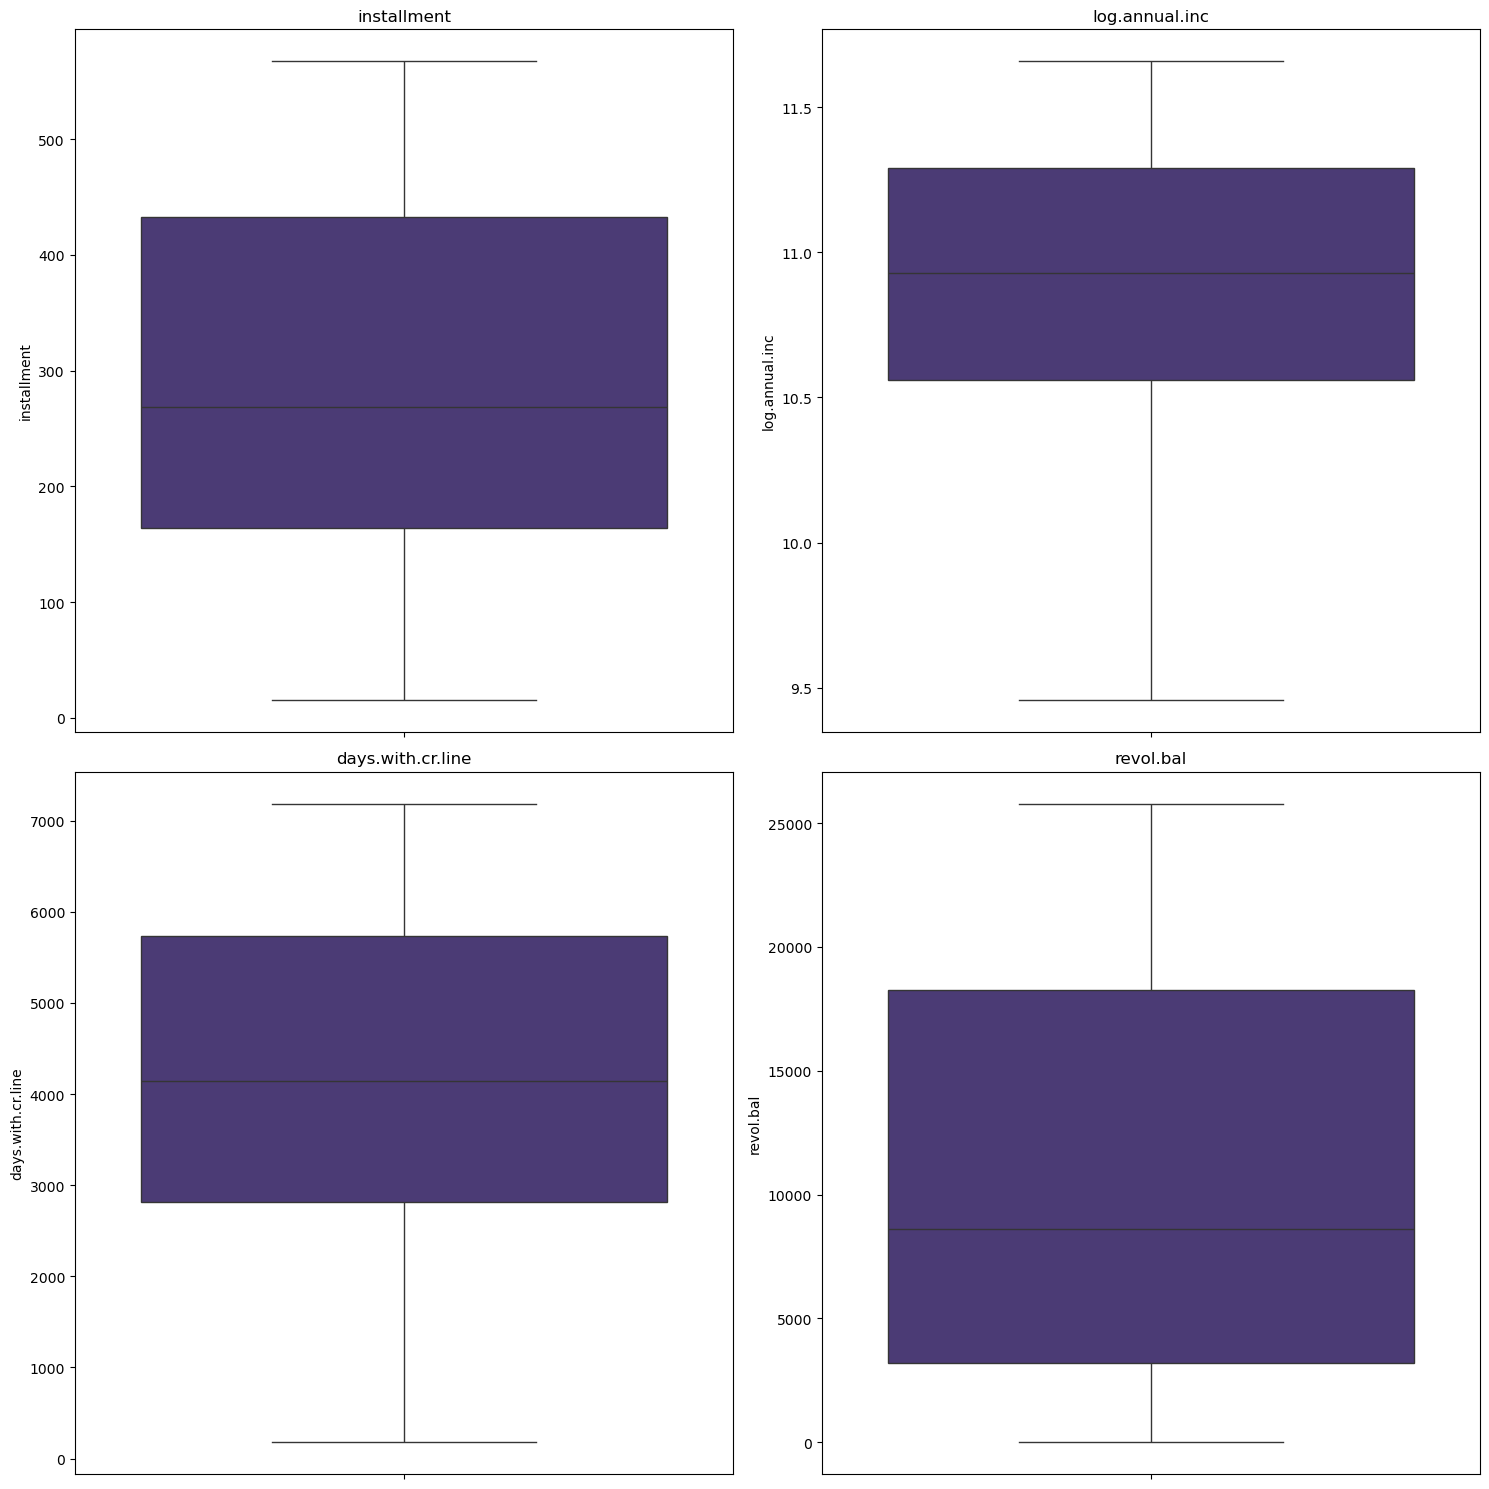

In [42]:
outliers_col = ['installment', 'log.annual.inc', 'days.with.cr.line', 'revol.bal']

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 15))
axes = axes.flatten()

for i, col in enumerate(outliers_col):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

In [43]:
df.head(3)

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,567.25875,11.350407,19.48,737,5639.958333,25780.75,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22000,11.082143,14.29,707,2760.000000,25780.75,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86000,10.373491,11.63,682,4710.000000,3511.00,25.6,1,0,0,0


In [44]:
df.columns = df.columns.str.replace('.', '_', regex=False)

df.head(3)

,credit_policy,purpose,int_rate,installment,log_annual_inc,dti,fico,days_with_cr_line,revol_bal,revol_util,inq_last_6mths,delinq_2yrs,pub_rec,not_fully_paid
0,1,debt_consolidation,0.1189,567.25875,11.350407,19.48,737,5639.958333,25780.75,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22000,11.082143,14.29,707,2760.000000,25780.75,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86000,10.373491,11.63,682,4710.000000,3511.00,25.6,1,0,0,0


## Data Preprocessing

In [50]:
df['purpose'].value_counts()

purpose
debt_consolidation    3957
all_other             2331
credit_card           1262
home_improvement       629
small_business         619
major_purchase         437
educational            343
Name: count, dtype: int64

In [51]:
df = pd.get_dummies(df, columns=['purpose'], drop_first=True)

In [52]:
bool_cols = df.select_dtypes(include=['bool']).columns
df[bool_cols] = df[bool_cols].astype(int)

df.head(3)

,credit_policy,int_rate,installment,log_annual_inc,dti,fico,days_with_cr_line,revol_bal,revol_util,inq_last_6mths,delinq_2yrs,pub_rec,not_fully_paid,purpose_credit_card,purpose_debt_consolidation,purpose_educational,purpose_home_improvement,purpose_major_purchase,purpose_small_business
0,1,0.1189,567.25875,11.350407,19.48,737,5639.958333,25780.75,52.1,0,0,0,0,0,1,0,0,0,0
1,1,0.1071,228.22000,11.082143,14.29,707,2760.000000,25780.75,76.7,0,0,0,0,1,0,0,0,0,0
2,1,0.1357,366.86000,10.373491,11.63,682,4710.000000,3511.00,25.6,1,0,0,0,0,1,0,0,0,0


## Feature Engineering

In [53]:
df['risk_score'] = df['dti'] * df['int_rate']

In [54]:
df['utilization_fico_ratio'] = (
    df['revol_util'] / df['fico']
)

In [55]:
df['income_installment_ratio'] = (
    df['log_annual_inc'] / df['installment']
)

## Heatmap

<Axes: >

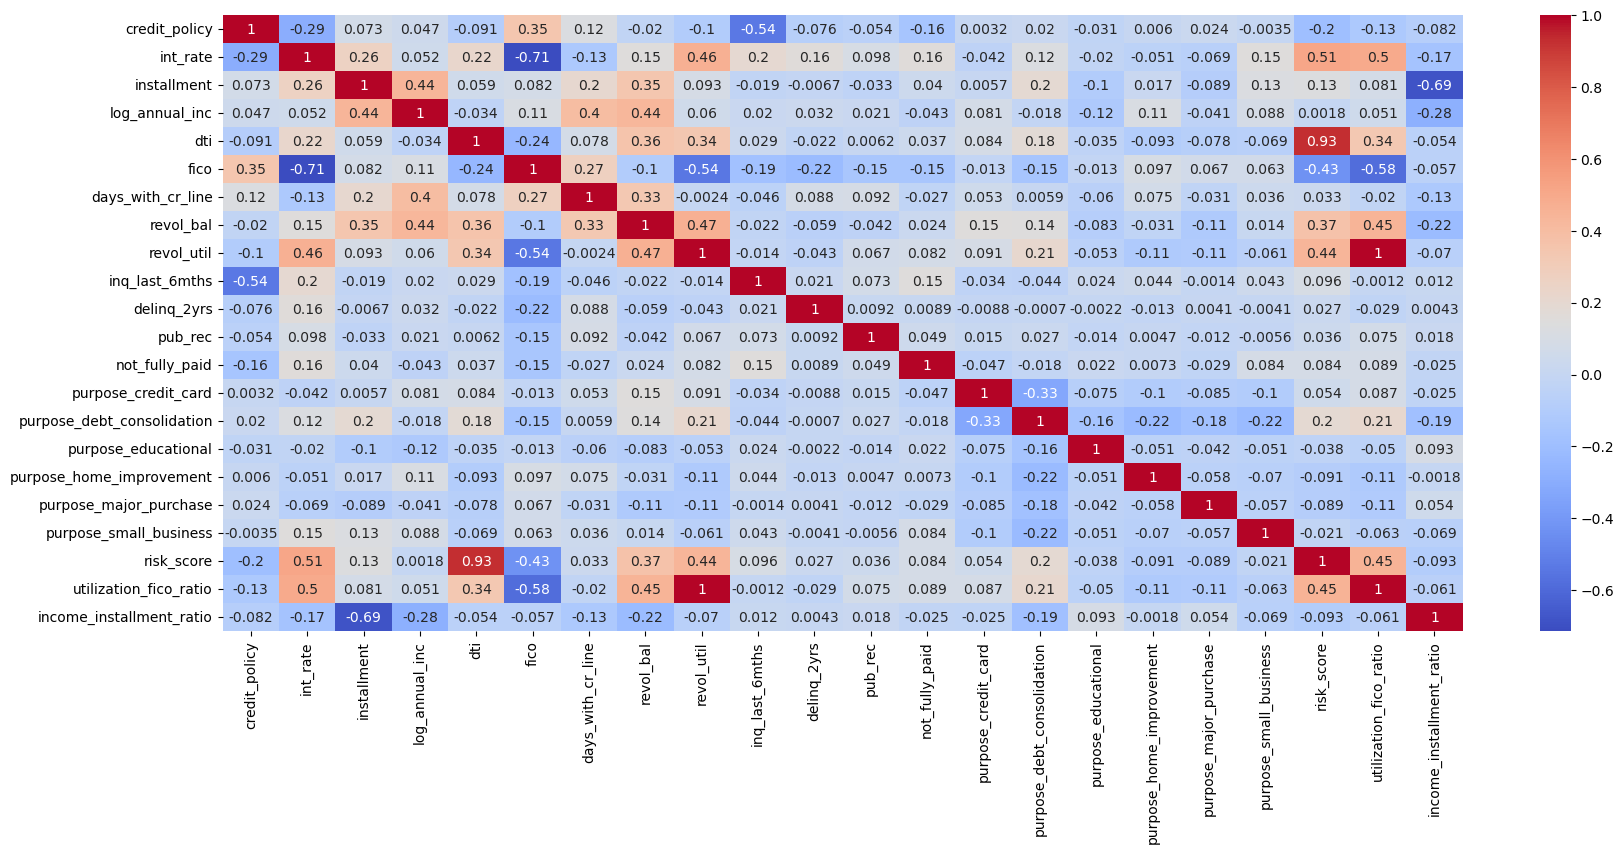

In [58]:
plt.figure(figsize=(20,8))

sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm', annot = True)

In [60]:
selected_features = [
    'credit_policy',
    'int_rate',
    'fico',
    'revol_util',
    'inq_last_6mths',
    'purpose_debt_consolidation',
    'purpose_small_business',
    'risk_score',
    'utilization_fico_ratio',
    'not_fully_paid'
]

df_cleaned = df[selected_features]

In [70]:
df_0 = df_cleaned[df_cleaned['not_fully_paid'] == 0]
df_1 = df_cleaned[df_cleaned['not_fully_paid'] == 1]

df_0_sample = df_0.sample(n=1533, random_state=42)

df_balanced = pd.concat([df_0_sample, df_1])

df_balanced = df_balanced.sample(frac=1, random_state=42)

df_balanced['not_fully_paid'].value_counts()

not_fully_paid
0    1533
1    1533
Name: count, dtype: int64

## Train Test Split

In [71]:
X = df_balanced.drop('not_fully_paid', axis=1)
y = df_balanced['not_fully_paid']

In [72]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

##  Feature Scaling

In [73]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

##  Logistic Regression

In [74]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

## Predictions

In [75]:
y_pred = model.predict(X_test_scaled)

## Evaluation

### Accuracy

In [76]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.6009771986970684


### Confusion Matrix

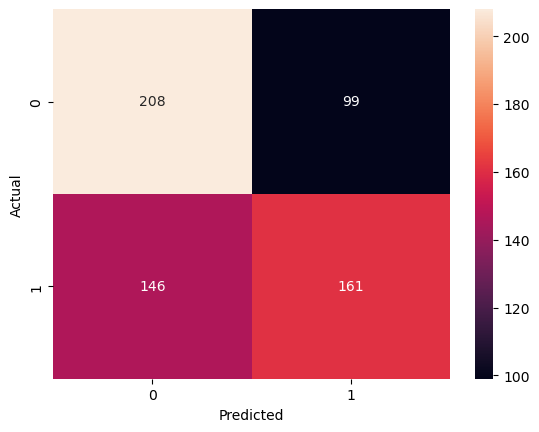

In [77]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Classification Report

In [78]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.59      0.68      0.63       307
           1       0.62      0.52      0.57       307

    accuracy                           0.60       614
   macro avg       0.60      0.60      0.60       614
weighted avg       0.60      0.60      0.60       614



## Conclusion